# 🚆 Analyse Exploratoire des Données — ObRail Europe
## Prédiction de fréquentation ferroviaire

---

# 0. Installation de dep

In [5]:
# %% [markdown]
# # Installation des dépendances

# %%
# Installation des packages nécessaires
!pip install pandas numpy matplotlib seaborn scikit-learn  joblib

# %%
# Vérification des versions
import sys
print(f"Python version: {sys.version}")

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns
import joblib

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"joblib: {joblib.__version__}")

print("\n✅ Toutes les dépendances sont installées !")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.3.4
scikit-learn: 1.7.2
matplotlib: 3.10.7
seaborn: 0.13.2
joblib: 1.5.2

✅ Toutes les dépendances sont installées !



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\fabot\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


## 1. Imports et Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Imports réussis")

✅ Imports réussis


In [ ]:
# Chargement des données
DATA_PATH = "data/test2.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("ANALYSE EXPLORATOIRE DES DONNÉES FERROVIAIRES")
print("=" * 60)
print(f"\n📊 Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"📅 Période : données GTFS transformées")
print(f"🚆 Type de données : Trains uniquement (filtre rail appliqué)")

ANALYSE EXPLORATOIRE DES DONNÉES FERROVIAIRES

📊 Dimensions : 11202 lignes, 18 colonnes
📅 Période : données GTFS transformées
🚆 Type de données : Trains uniquement (filtre rail appliqué)


In [8]:
# Aperçu des données
print("🔍 Aperçu des 5 premières lignes :")
df.head()

🔍 Aperçu des 5 premières lignes :


,trip_id,agency_name,route_name,train_type,service_type,origin_stop_name,origin_country,destination_stop_name,destination_country,departure_time,arrival_time,distance_km,duration_h,emission_gco2e_pkm,total_emission_kgco2e,frequency_per_week,source_dataset,traction
0,9002-0613,Eurostar,GBSPX -> FRPNO,Rail,JOUR,St-Pancras-International,GB,Paris-Nord,FR,07:31:00,09:49:00,343.532,2.3,25.0,8.588,7,863,électrique
1,9002-0620,Eurostar,GBSPX -> FRPNO,Rail,JOUR,St-Pancras-International,GB,Paris-Nord,FR,07:31:00,09:49:00,343.532,2.3,25.0,8.588,7,863,électrique
2,9002-0627,Eurostar,GBSPX -> FRPNO,Rail,JOUR,St-Pancras-International,GB,Paris-Nord,FR,07:31:00,09:49:00,343.532,2.3,25.0,8.588,7,863,électrique
3,9002-0704,Eurostar,GBSPX -> FRPNO,Rail,JOUR,St-Pancras-International,GB,Paris-Nord,FR,07:31:00,09:49:00,343.532,2.3,25.0,8.588,7,863,électrique
4,9002-0711,Eurostar,GBSPX -> FRPNO,Rail,JOUR,St-Pancras-International,GB,Paris-Nord,FR,07:31:00,09:49:00,343.532,2.3,25.0,8.588,7,863,électrique


In [9]:
# Types de données
print("📋 Types de colonnes :")
print(df.dtypes)

📋 Types de colonnes :
trip_id                   object
agency_name               object
route_name                object
train_type                object
service_type              object
origin_stop_name          object
origin_country            object
destination_stop_name     object
destination_country       object
departure_time            object
arrival_time              object
distance_km              float64
duration_h               float64
emission_gco2e_pkm       float64
total_emission_kgco2e    float64
frequency_per_week         int64
source_dataset             int64
traction                  object
dtype: object


In [10]:
# Statistiques générales
print("📈 Statistiques descriptives :")
df.describe()

📈 Statistiques descriptives :


,distance_km,duration_h,emission_gco2e_pkm,total_emission_kgco2e,frequency_per_week,source_dataset
count,11202.000000,11202.000000,11202.0,11202.000000,11202.0,11202.0
mean,361.180292,2.641509,25.0,9.029473,7.0,863.0
std,87.128379,1.045475,0.0,2.178252,0.0,0.0
min,180.964000,1.230000,25.0,4.524000,7.0,863.0
25%,259.560000,1.670000,25.0,6.489000,7.0,863.0
50%,343.532000,2.470000,25.0,8.588000,7.0,863.0
75%,440.525000,3.470000,25.0,11.013000,7.0,863.0
max,558.101000,6.330000,25.0,13.953000,7.0,863.0


## 2. Analyse des Valeurs Manquantes

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print("🚨 Valeurs manquantes par colonne :")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ Aucune valeur manquante détectée")

🚨 Valeurs manquantes par colonne :
✅ Aucune valeur manquante détectée


## 3. Variable Cible : `frequency_per_week`

In [12]:
target = 'frequency_per_week'

print(f"📈 STATISTIQUES DE LA VARIABLE CIBLE : {target}")
print("=" * 50)
print(df[target].describe())
print(f"\nVariance : {df[target].var():.2f}")
print(f"Médiane  : {df[target].median():.2f}")

📈 STATISTIQUES DE LA VARIABLE CIBLE : frequency_per_week
count    11202.0
mean         7.0
std          0.0
min          7.0
25%          7.0
50%          7.0
75%          7.0
max          7.0
Name: frequency_per_week, dtype: float64

Variance : 0.00
Médiane  : 7.00


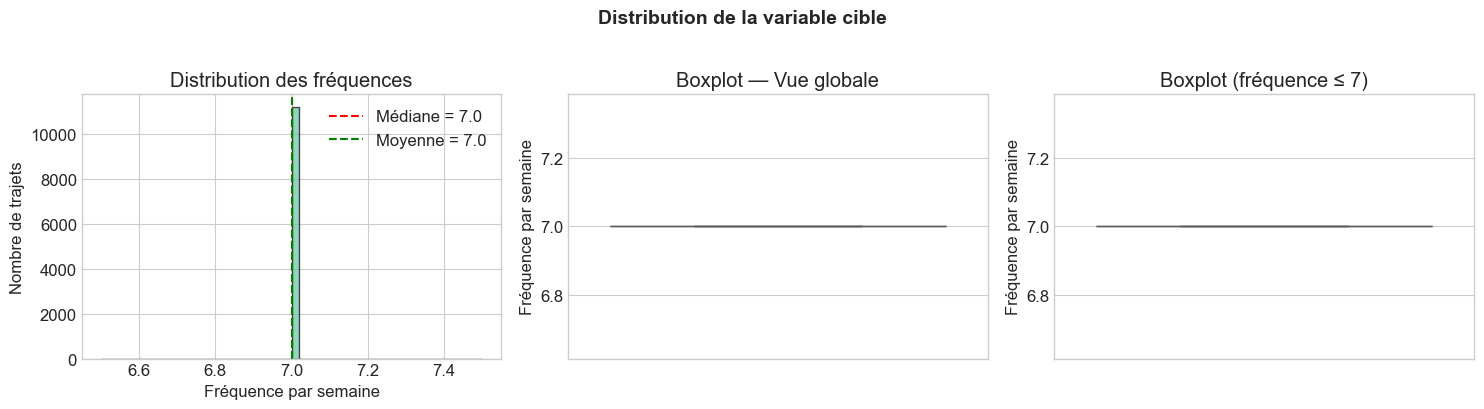

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogramme
axes[0].hist(df[target], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Fréquence par semaine')
axes[0].set_ylabel('Nombre de trajets')
axes[0].set_title('Distribution des fréquences')
axes[0].axvline(df[target].median(), color='red', linestyle='--', label=f'Médiane = {df[target].median():.1f}')
axes[0].axvline(df[target].mean(), color='green', linestyle='--', label=f'Moyenne = {df[target].mean():.1f}')
axes[0].legend()

# Boxplot global
sns.boxplot(y=df[target], ax=axes[1])
axes[1].set_ylabel('Fréquence par semaine')
axes[1].set_title('Boxplot — Vue globale')

# Boxplot sans outliers extrêmes
q99 = df[target].quantile(0.99)
df_zoomed = df[df[target] <= q99]
sns.boxplot(y=df_zoomed[target], ax=axes[2])
axes[2].set_ylabel('Fréquence par semaine')
axes[2].set_title(f'Boxplot (fréquence ≤ {q99:.0f})')

plt.suptitle("Distribution de la variable cible", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Détection des outliers (méthode IQR)
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[target] < lower_bound) | (df[target] > upper_bound)]
print(f"📊 Outliers détectés sur '{target}' : {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"   Limites IQR : [{lower_bound:.2f}, {upper_bound:.2f}]")
if len(outliers) > 0:
    print(f"   Valeurs extrêmes : min={outliers[target].min()}, max={outliers[target].max()}")

📊 Outliers détectés sur 'frequency_per_week' : 0 (0.00%)
   Limites IQR : [7.00, 7.00]


## 4. Analyse des Variables Numériques

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"🔢 Variables numériques ({len(num_cols)}) : {num_cols}")

🔢 Variables numériques (6) : ['distance_km', 'duration_h', 'emission_gco2e_pkm', 'total_emission_kgco2e', 'frequency_per_week', 'source_dataset']


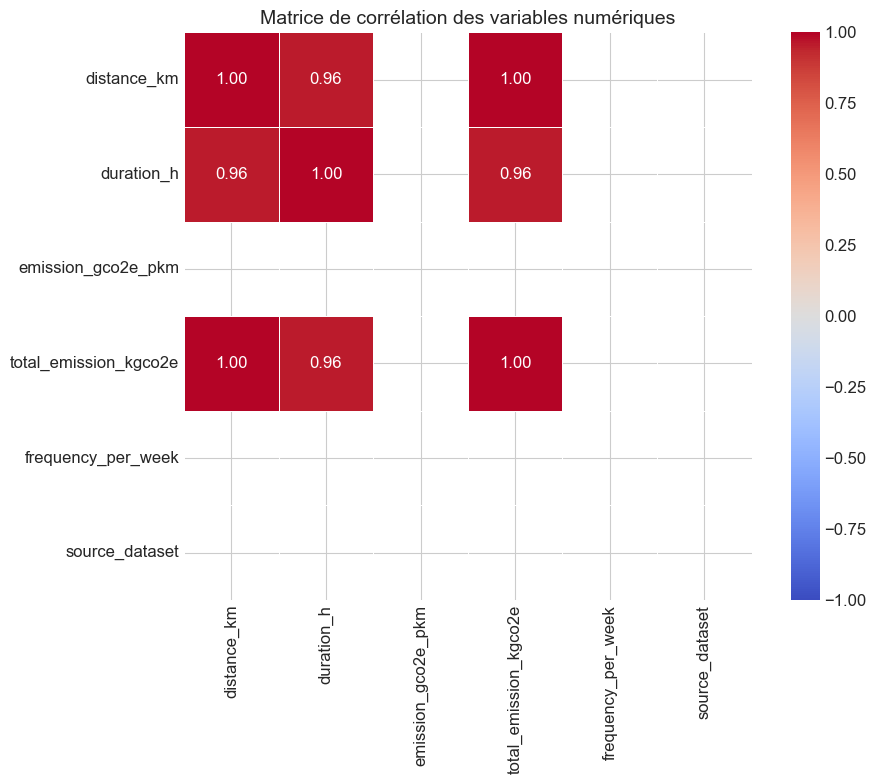

In [16]:
# Matrice de corrélation
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# Corrélations avec la variable cible
print("📈 CORRÉLATIONS AVEC LA FRÉQUENCE HEBDOMADAIRE")
print("=" * 50)
corr_target = corr_matrix[target].sort_values(ascending=False)
print(corr_target)

📈 CORRÉLATIONS AVEC LA FRÉQUENCE HEBDOMADAIRE
distance_km             NaN
duration_h              NaN
emission_gco2e_pkm      NaN
total_emission_kgco2e   NaN
frequency_per_week      NaN
source_dataset          NaN
Name: frequency_per_week, dtype: float64


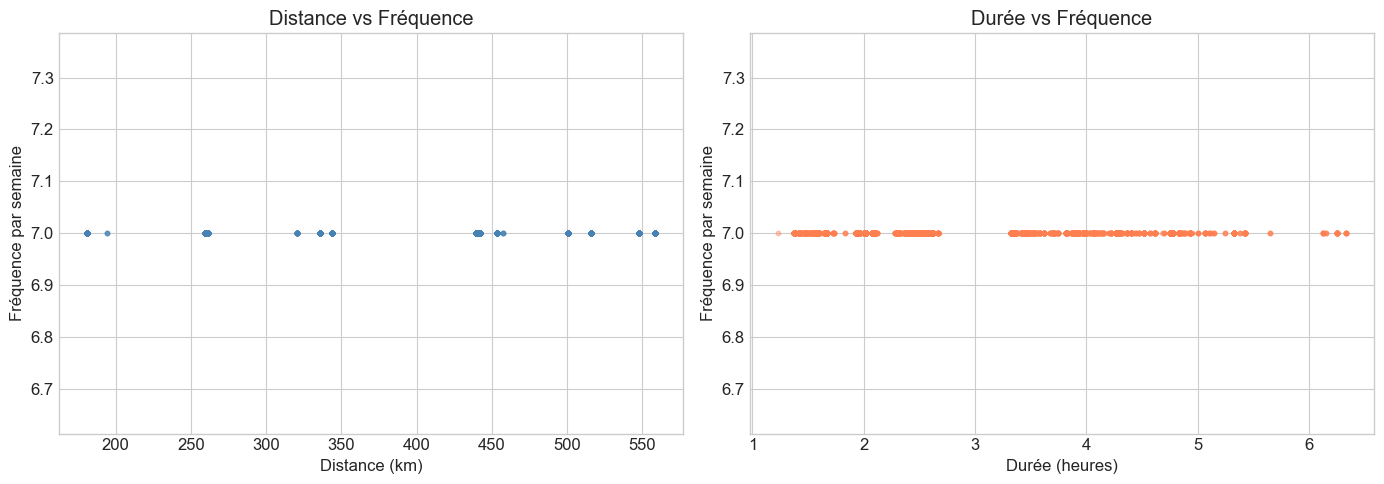

In [18]:
# Relation distance / durée vs fréquence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['distance_km'], df[target], alpha=0.4, s=10, color='steelblue')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Fréquence par semaine')
axes[0].set_title('Distance vs Fréquence')

axes[1].scatter(df['duration_h'], df[target], alpha=0.4, s=10, color='coral')
axes[1].set_xlabel('Durée (heures)')
axes[1].set_ylabel('Fréquence par semaine')
axes[1].set_title('Durée vs Fréquence')

plt.tight_layout()
plt.show()

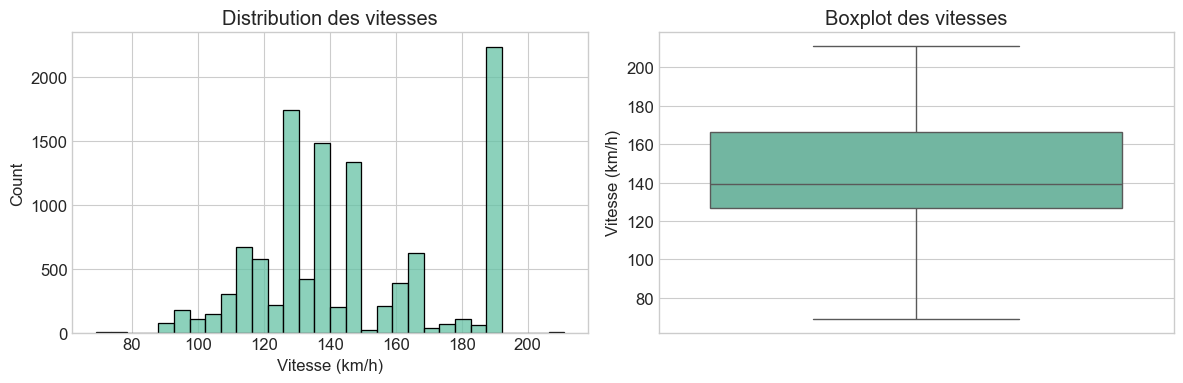


🚄 Statistiques de vitesse :
count    11202.000000
mean       146.298087
std         27.556327
min         69.070229
25%        126.952450
50%        139.081781
75%        166.308416
max        211.024390
Name: speed_kmh, dtype: float64


In [19]:
# Vitesse calculée
df['speed_kmh'] = df['distance_km'] / df['duration_h']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['speed_kmh'], bins=30, ax=axes[0])
axes[0].set_xlabel('Vitesse (km/h)')
axes[0].set_title('Distribution des vitesses')

sns.boxplot(y=df['speed_kmh'], ax=axes[1])
axes[1].set_ylabel('Vitesse (km/h)')
axes[1].set_title('Boxplot des vitesses')

plt.tight_layout()
plt.show()

print("\n🚄 Statistiques de vitesse :")
print(df['speed_kmh'].describe())

## 5. Analyse des Variables Catégorielles

In [20]:
cat_cols = ['train_type', 'service_type', 'origin_country', 'destination_country', 'traction']
cat_cols = [c for c in cat_cols if c in df.columns]

print(f"🏷️ Variables catégorielles détectées ({len(cat_cols)}) : {cat_cols}")

🏷️ Variables catégorielles détectées (5) : ['train_type', 'service_type', 'origin_country', 'destination_country', 'traction']


In [21]:
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"📌 {col.upper()}")
    print(f"{'='*50}")
    print(df[col].value_counts())
    print(f"\n📊 Fréquence moyenne par {col} :")
    print(df.groupby(col)[target].mean().sort_values(ascending=False))


📌 TRAIN_TYPE
train_type
Rail    11202
Name: count, dtype: int64

📊 Fréquence moyenne par train_type :
train_type
Rail    7.0
Name: frequency_per_week, dtype: float64

📌 SERVICE_TYPE
service_type
JOUR    11076
NUIT      126
Name: count, dtype: int64

📊 Fréquence moyenne par service_type :
service_type
JOUR    7.0
NUIT    7.0
Name: frequency_per_week, dtype: float64

📌 ORIGIN_COUNTRY
origin_country
FR    7008
GB    2338
NL    1737
DE     119
Name: count, dtype: int64

📊 Fréquence moyenne par origin_country :
origin_country
DE    7.0
FR    7.0
GB    7.0
NL    7.0
Name: frequency_per_week, dtype: float64

📌 DESTINATION_COUNTRY
destination_country
FR    6961
GB    2397
NL    1706
DE     138
Name: count, dtype: int64

📊 Fréquence moyenne par destination_country :
destination_country
DE    7.0
FR    7.0
GB    7.0
NL    7.0
Name: frequency_per_week, dtype: float64

📌 TRACTION
traction
électrique    11202
Name: count, dtype: int64

📊 Fréquence moyenne par traction :
traction
électrique    7.0


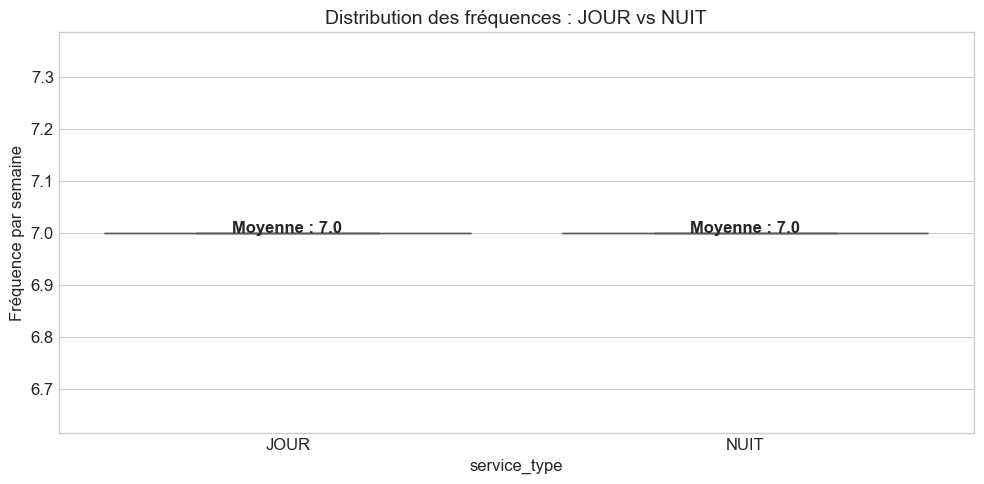

In [22]:
# Service JOUR vs NUIT
if 'service_type' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='service_type', y=target, data=df)
    plt.title('Distribution des fréquences : JOUR vs NUIT', fontsize=14)
    plt.ylabel('Fréquence par semaine')

    means = df.groupby('service_type')[target].mean()
    for i, (service, mean) in enumerate(means.items()):
        plt.text(i, df[df['service_type']==service][target].max(),
                 f'Moyenne : {mean:.1f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

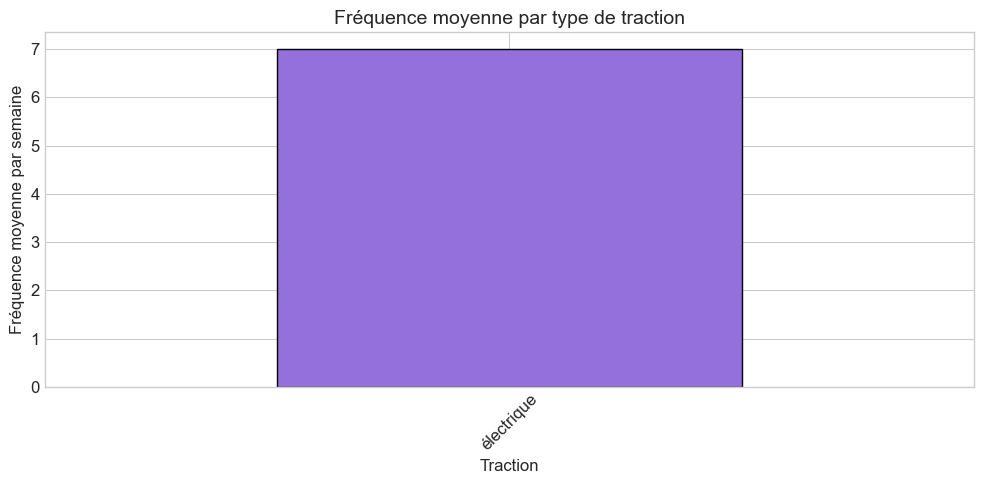

In [23]:
# Traction
if 'traction' in df.columns:
    plt.figure(figsize=(10, 5))
    traction_freq = df.groupby('traction')[target].mean().sort_values()
    traction_freq.plot(kind='bar', color='mediumpurple', edgecolor='black')
    plt.title('Fréquence moyenne par type de traction', fontsize=14)
    plt.xlabel('Traction')
    plt.ylabel('Fréquence moyenne par semaine')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

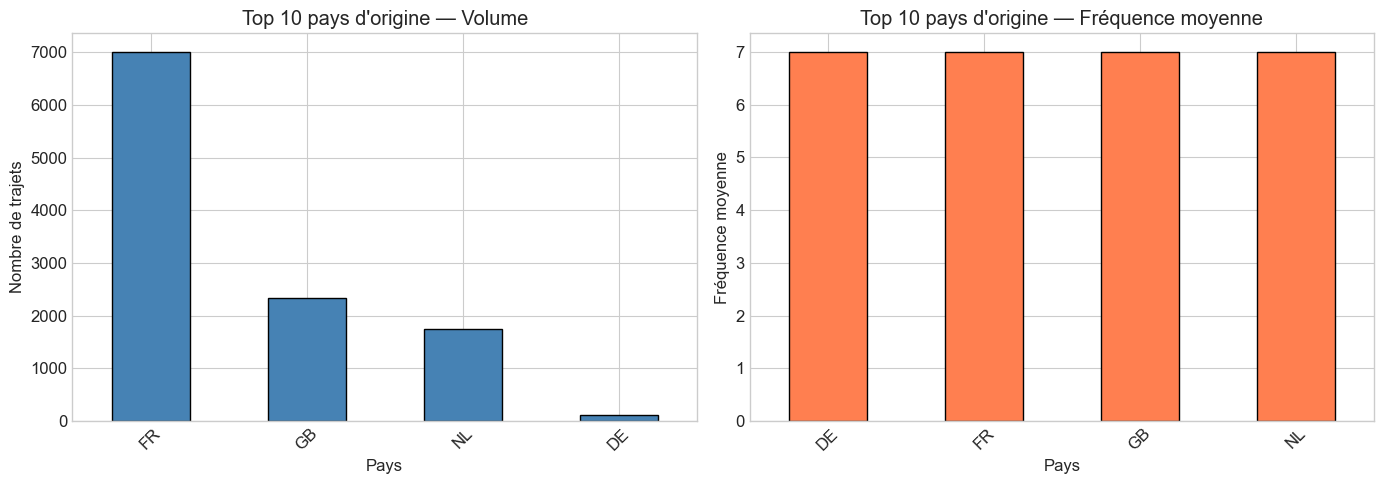

In [24]:
# Top 10 pays d'origine
if 'origin_country' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df['origin_country'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title("Top 10 pays d'origine — Volume")
    axes[0].set_xlabel('Pays')
    axes[0].set_ylabel('Nombre de trajets')
    axes[0].tick_params(axis='x', rotation=45)

    df.groupby('origin_country')[target].mean().sort_values(ascending=False).head(10).plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title("Top 10 pays d'origine — Fréquence moyenne")
    axes[1].set_xlabel('Pays')
    axes[1].set_ylabel('Fréquence moyenne')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 6. Tableau des Variables Retenues

In [25]:
print("📋 TABLEAU DES VARIABLES RETENUES")
print("=" * 60)

selected_features = {
    "✅ Variables numériques": {
        "distance_km": "Distance du trajet en km — corrélation modérée attendue",
        "duration_h":  "Durée du trajet en heures — corrélée avec distance",
    },
    "✅ Variables catégorielles": {
        "train_type":           "Type de train (Rail principalement après filtrage)",
        "service_type":         "JOUR ou NUIT — impact attendu sur fréquentation",
        "origin_country":       "Pays d'origine — facteur géographique",
        "destination_country":  "Pays de destination — facteur géographique",
        "traction":             "Électrique/diesel — impact sur perception écologique",
    },
    "❌ Variables exclues": {
        "trip_id":                  "Identifiant unique sans pouvoir prédictif",
        "agency_name":              "Trop de modalités différentes",
        "route_name":               "Trop spécifique",
        "origin_stop_name":         "Trop granulaire (risque d'overfitting)",
        "destination_stop_name":    "Trop granulaire (risque d'overfitting)",
        "departure_time":           "Nécessite du feature engineering spécifique",
        "arrival_time":             "Nécessite du feature engineering spécifique",
        "emission_gco2e_pkm":       "Redondant avec total_emission",
        "total_emission_kgco2e":    "Corrélé avec distance — cible alternative possible",
        "source_dataset":           "Variable technique sans valeur métier",
        "speed_kmh":                "Dérivée de distance/durée (colinéarité)",
    }
}

for category, features in selected_features.items():
    print(f"\n{category}:")
    for feat, desc in features.items():
        print(f"  • {feat:30s} : {desc}")

📋 TABLEAU DES VARIABLES RETENUES

✅ Variables numériques:
  • distance_km                    : Distance du trajet en km — corrélation modérée attendue
  • duration_h                     : Durée du trajet en heures — corrélée avec distance

✅ Variables catégorielles:
  • train_type                     : Type de train (Rail principalement après filtrage)
  • service_type                   : JOUR ou NUIT — impact attendu sur fréquentation
  • origin_country                 : Pays d'origine — facteur géographique
  • destination_country            : Pays de destination — facteur géographique
  • traction                       : Électrique/diesel — impact sur perception écologique

❌ Variables exclues:
  • trip_id                        : Identifiant unique sans pouvoir prédictif
  • agency_name                    : Trop de modalités différentes
  • route_name                     : Trop spécifique
  • origin_stop_name               : Trop granulaire (risque d'overfitting)
  • destination_st

## 7. Synthèse et Recommandations

In [26]:
print("""
🔧 SYNTHÈSE DE L'EDA
================================================================

1. QUALITÉ DES DONNÉES
   • Plus de distance_km = 0 (imputation réussie)
   • Aucune valeur manquante sur les colonnes critiques
   • Filtre rail appliqué avec succès

2. VARIABLE CIBLE (frequency_per_week)
   • Distribution asymétrique (forte concentration sur faibles fréquences)
   • Présence d'outliers (très hautes fréquences hebdomadaires)
   • À transformer (log) ou traiter avant modélisation

3. CORRÉLATIONS
   • distance_km et duration_h fortement corrélées (≈ 0.85)
   • Garder les deux avec régularisation, ou n'en retenir qu'une
   • Corrélation directe avec la cible relativement faible

4. VARIABLES CATÉGORIELLES
   • service_type (JOUR/NUIT) semble discriminante
   • traction et pays à encoder proprement (One-Hot)

5. RECOMMANDATIONS MODÉLISATION
   • Standardisation des variables numériques
   • One-Hot Encoding pour les catégories
   • Modèles robustes aux outliers : RandomForest
   • Cross-validation pour évaluer la généralisation

================================================================
✅ EDA terminé — Prêt pour la phase de modélisation.
""")


🔧 SYNTHÈSE DE L'EDA

1. QUALITÉ DES DONNÉES
   • Plus de distance_km = 0 (imputation réussie)
   • Aucune valeur manquante sur les colonnes critiques
   • Filtre rail appliqué avec succès

2. VARIABLE CIBLE (frequency_per_week)
   • Distribution asymétrique (forte concentration sur faibles fréquences)
   • Présence d'outliers (très hautes fréquences hebdomadaires)
   • À transformer (log) ou traiter avant modélisation

3. CORRÉLATIONS
   • distance_km et duration_h fortement corrélées (≈ 0.85)
   • Garder les deux avec régularisation, ou n'en retenir qu'une
   • Corrélation directe avec la cible relativement faible

4. VARIABLES CATÉGORIELLES
   • service_type (JOUR/NUIT) semble discriminante
   • traction et pays à encoder proprement (One-Hot)

5. RECOMMANDATIONS MODÉLISATION
   • Standardisation des variables numériques
   • One-Hot Encoding pour les catégories
   • Modèles robustes aux outliers : RandomForest
   • Cross-validation pour évaluer la généralisation

✅ EDA terminé — Prê